<a href="https://colab.research.google.com/github/dhanushkumar-amk/PYTHON-AI-ML-INTERNSHIP/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Imports**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

print("All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

All libraries imported successfully!
TensorFlow version: 2.20.0


### **Load and Preprocess CIFAR-10 Dataset**

In [ ]:
# Load dataset (auto downloads ~170MB)
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Normalize pixel values to [0, 1]
X_train = X_train.astype('float32') / 255.0
X_test  = X_test.astype('float32')  / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print(f"Training samples : {X_train.shape}")
print(f"Test samples     : {X_test.shape}")
print("Preprocessing done!")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training samples : (50000, 32, 32, 3)
Test samples     : (10000, 32, 32, 3)
Preprocessing done!


### **Build CNN Model**

In [ ]:
model = models.Sequential([

    # Block 1
    layers.Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.40),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.50),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 621,258 (2.37 MB)

 Trainable params: 620,810 (2.37 MB)

 Non-trainable params: 448 (1.75 KB)

### **Compile the Model**

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


### **Train the Model**

In [ ]:
history = model.fit(
    X_train, y_train_cat,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test_cat),
    verbose=1
)

print("Training complete!")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 207s 260ms/step - accuracy: 0.3690 - loss: 1.7693 - val_accuracy: 0.5141 - val_loss: 1.3402
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 182s 232ms/step - accuracy: 0.4918 - loss: 1.4069 - val_accuracy: 0.5908 - val_loss: 1.1372
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 169s 217ms/step - accuracy: 0.5593 - loss: 1.2475 - val_accuracy: 0.6066 - val_loss: 1.1156
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 200s 214ms/step - accuracy: 0.5956 - loss: 1.1468 - val_accuracy: 0.6453 - val_loss: 1.0109
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 207s 220ms/step - accuracy: 0.6266 - loss: 1.0616 - val_accuracy: 0.6433 - val_loss: 1.0331
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 199s 217ms/step - accuracy: 0.6488 - loss: 1.0067 - val_accuracy: 0.6730 - val_loss: 0.9160
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 215ms/step - accuracy: 0.6674 - loss: 0.9587 - val_accuracy: 0.7170 - val_loss: 0.8227
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 168s 215ms/step - accuracy: 0.6816 -

### **Evaluate the Model**

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=0)

print(f"Test Accuracy : {test_acc*100:.2f}%")
print(f"Test Loss     : {test_loss:.4f}")

Test Accuracy : 61.60%
Test Loss     : 1.1728


### **Plot Training Curves**

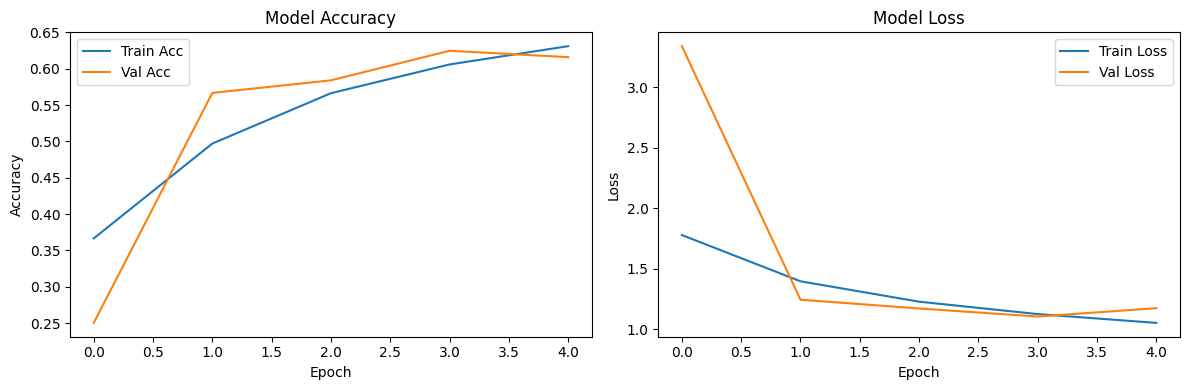

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

### **Save The Model**


In [ ]:
model.save('best_cnn_model.h5')
print("Model saved as best_cnn_model.h5")

Model saved as best_cnn_model.h5


### **Predictions**

In [ ]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

print("Predictions done!")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Predictions done!


### **Classification Report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.59      0.76      0.66      1000
  automobile       0.86      0.62      0.72      1000
        bird       0.58      0.45      0.50      1000
         cat       0.58      0.28      0.37      1000
        deer       0.56      0.62      0.59      1000
         dog       0.80      0.26      0.39      1000
        frog       0.84      0.60      0.70      1000
       horse       0.57      0.81      0.67      1000
        ship       0.62      0.85      0.72      1000
       truck       0.51      0.92      0.65      1000

    accuracy                           0.62     10000
   macro avg       0.65      0.62      0.60     10000
weighted avg       0.65      0.62      0.60     10000



### **Confusion Matrix**

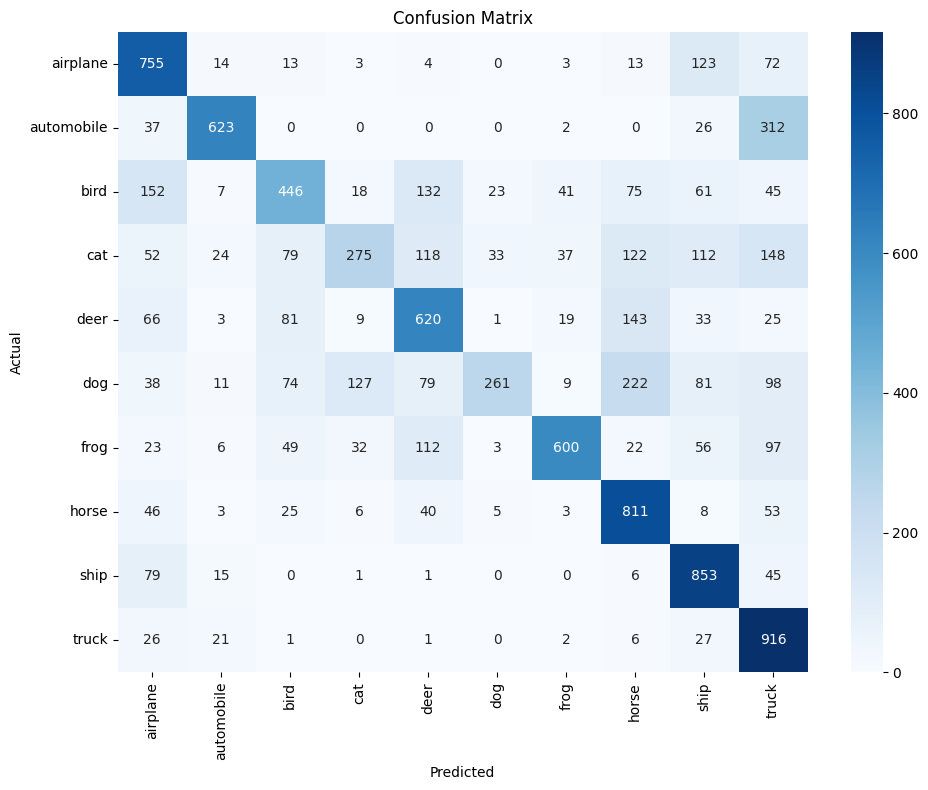

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### **Visualize Sample Predictions**

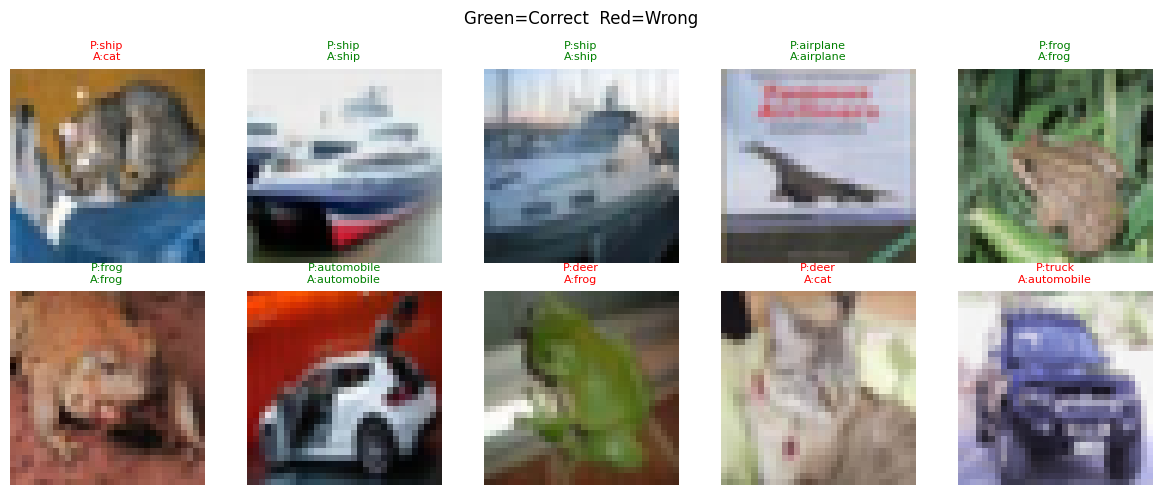

In [ ]:
plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_test[i])
    pred   = class_names[y_pred[i]]
    actual = class_names[y_true[i]]
    color  = 'green' if pred == actual else 'red'
    plt.title(f"P:{pred}\nA:{actual}", color=color, fontsize=8)
    plt.axis('off')
plt.suptitle("Green=Correct  Red=Wrong")
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
files.download('best_cnn_model.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>